**File Name:** BMW Sales Data (2010–2024).csv

**File Type:** CSV (Comma-Separated Values)

**Data Format:** Structured tabular data

**Time Period Covered:** 2010 to 2024

**Industry:** Automobile / Automotive Sales

**Company:** BMW (Bayerische Motoren Werke)

**Data Scope:** Global sales and vehicle specifications

**Number of Records:** Contains multiple entries for BMW models across years

**Number of Columns:** Includes vehicle details, technical specifications, and sales performance attributes

**Intended Use:** Data analysis, academic projects, business insights, trend analysis, and visualization

1. data loading

In [ ]:
import pandas as pd
df = pd.read_csv('/content/BMW sales data (2010-2024).csv')

print('dataframe is loaded')
print(df.shape)
df.head()

dataframe is loaded
(50000, 11)


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


2. under stading the data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [ ]:
df.columns

Index(['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission',
       'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume',
       'Sales_Classification'],
      dtype='object')

In [ ]:
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [ ]:
print(df['Model'].unique())
print(df['Model'].nunique())

['5 Series' 'i8' 'X3' '7 Series' 'M5' '3 Series' 'X1' 'M3' 'X5' 'i3' 'X6']
11


In [ ]:
df.sample(5)

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
26793,X3,2018,Africa,Red,Petrol,Automatic,2.9,55272,84237,1486,Low
39298,i3,2024,Asia,White,Diesel,Manual,4.6,57768,115374,9087,High
10504,i3,2011,Europe,Silver,Electric,Automatic,2.7,149311,43541,3728,Low
49679,i3,2010,Asia,Blue,Petrol,Automatic,4.0,132790,72814,2216,Low
16934,i8,2011,Africa,Black,Hybrid,Automatic,4.1,198115,41104,3417,Low


In [ ]:
print(df['Region'].unique())

['Asia' 'North America' 'Middle East' 'South America' 'Europe' 'Africa']


this data set can be used for regressor classification problem as well as recommendation , we will go for recommendation

lastly i will try to make the report of this too using power bi

In [ ]:
df['Fuel_Type'].unique()

array(['Petrol', 'Hybrid', 'Diesel', 'Electric'], dtype=object)

3. data cleaning and removing not important columns .

In [ ]:
df.drop(columns=['Year','Sales_Volume','Sales_Classification'],inplace=True) # removing those sales related features

In [ ]:
df

,Model,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD
0,5 Series,Asia,Red,Petrol,Manual,3.5,151748,98740
1,i8,North America,Red,Hybrid,Automatic,1.6,121671,79219
2,5 Series,North America,Blue,Petrol,Automatic,4.5,10991,113265
3,X3,Middle East,Blue,Petrol,Automatic,1.7,27255,60971
4,7 Series,South America,Black,Diesel,Manual,2.1,122131,49898
...,...,...,...,...,...,...,...,...
49995,i3,Asia,Red,Hybrid,Manual,4.6,151030,42932
49996,i3,Middle East,Silver,Electric,Manual,4.2,147396,48714
49997,5 Series,Middle East,Red,Petrol,Automatic,4.5,174939,46126
49998,i3,Asia,White,Electric,Automatic,3.8,3379,58566


In [ ]:
cat_cols = ['Region','Color','Fuel_Type','Transmission']
num_cols = ['Engine_Size_L',	'Mileage_KM',	'Price_USD']

In [ ]:
df[num_cols].corr()

,Engine_Size_L,Mileage_KM,Price_USD
Engine_Size_L,1.000000,-0.004906,0.000146
Mileage_KM,-0.004906,1.000000,-0.004238
Price_USD,0.000146,-0.004238,1.000000


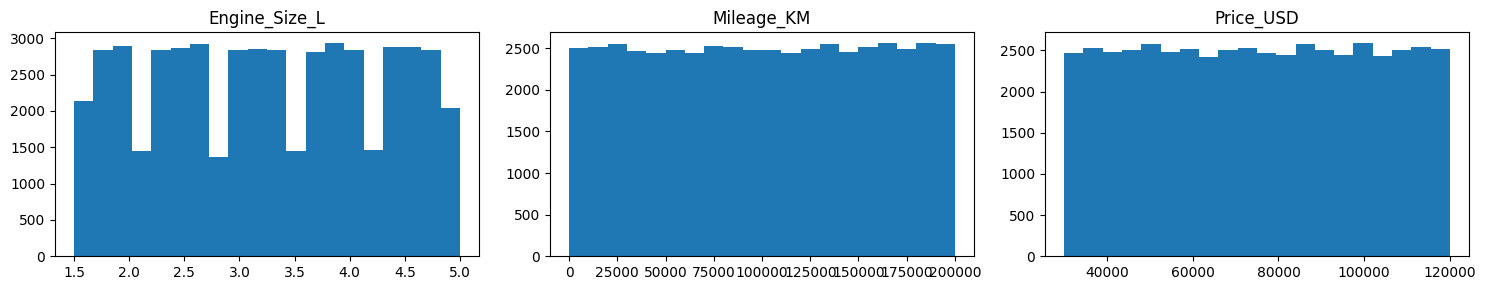

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, len(num_cols), figsize=(15, 3))
ax = ax.flatten()

for i , col in enumerate(num_cols):
  ax[i].hist(df[col],bins=20)
  ax[i].set_title(col)

plt.tight_layout()
plt.show()

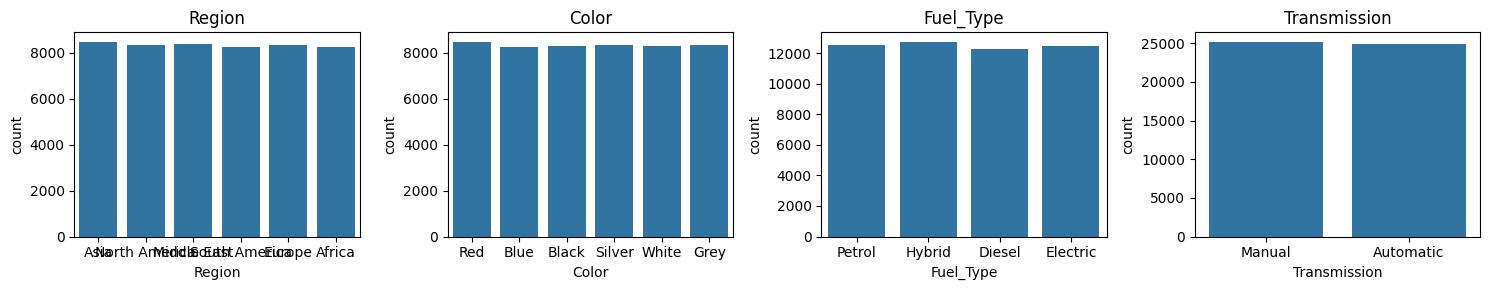

In [ ]:
fig, ax = plt.subplots(1, len(cat_cols), figsize=(15, 3))
ax = ax.flatten()

for i , col in enumerate(cat_cols):
  sns.countplot(x=df[col], ax=ax[i])
  ax[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# not much need of preprocessing
# every thing is balanced

approch 1 : we will  use the binning like technique to handel price and milage to the user to select .
apporch 2 : ask for the fixed price

we will go with second approch as the fixed price will be much relaiable , as only few buyers can increase their prices .

4. model normalising the price and encoding other columns  for the better performance of the model

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder , MinMaxScaler , StandardScaler
from sklearn.pipeline import Pipeline
# i am not using the column transformer but you can use that

In [ ]:
cat_cols = ['Region','Color','Fuel_Type','Transmission']
num_cols = ['Engine_Size_L',	'Mileage_KM']

# Create pipelines for preprocessing
# Pipeline for categorical features
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

# Pipeline for numerical features
numerical_pipeline = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

split the data into X and y

In [ ]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [ ]:
# first try with without any tansformation on X

In [ ]:
label_encod = LabelEncoder()
y_encoded = label_encod.fit_transform(y)

In [ ]:
mapping = dict(zip(y_encoded.classes_, range(len(y_encoded.classes_))))
mapping

{'3 Series': 0,
 '5 Series': 1,
 '7 Series': 2,
 'M3': 3,
 'M5': 4,
 'X1': 5,
 'X3': 6,
 'X5': 7,
 'X6': 8,
 'i3': 9,
 'i8': 10}

model building

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40000, 7), (10000, 7), (40000,), (10000,))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [ ]:
clf1 = KNeighborsClassifier()

In [ ]:
clf1.fit(X_train_processed_final,y_train)
y_pred = clf1.predict(X_test_processed_final)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.0869
[[201 147 106  76  59  68  52  40  46  44  57]
 [207 140  93  94  68  70  53  44  49  59  63]
 [211 159 107  81  59  65  55  50  41  52  55]
 [189 166 117  80  52  57  47  40  42  54  43]
 [194 158  94  68  65  69  53  50  51  43  48]
 [231 142 104  82  60  48  53  48  64  51  55]
 [228 141 108  64  59  51  47  37  49  57  45]
 [223 154 110  81  61  49  52  47  54  51  41]
 [209 160  97  63  72  55  50  49  41  44  46]
 [208 161 104  94  56  50  52  42  46  57  45]
 [210 164  82  90  74  56  54  49  39  47  36]]
              precision    recall  f1-score   support

           0       0.09      0.22      0.13       896
           1       0.08      0.15      0.11       940
           2       0.10      0.11      0.10       935
           3       0.09      0.09      0.09       887
           4       0.09      0.07      0.08       893
           5       0.08      0.05      0.06       938
           6       0.08      0.05      0.06       886
           7       0.09      0.05      0.0

In [ ]:
clf2 = LogisticRegression(multi_class='multinomial', solver='newton-cg', max_iter=1000, random_state=42) # Using 'newton-cg' for multinomial logistic regression with softmax
clf2.fit(X_train_processed_final, y_train)
y_pred_lr = clf2.predict(X_test_processed_final)

print("Logistic Regression with Softmax Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression with Softmax Results:
Accuracy: 0.0932
Confusion Matrix:
[[ 76 124 137   0  84 125  24  37  27 147 115]
 [ 61 131 146   1  71 151  33  26  41 163 116]
 [ 66 145 150   3  77 147  27  38  38 135 109]
 [ 81 133 164   2  64 118  30  28  37 150  80]
 [ 60 160 144   2  72 122  27  32  36 137 101]
 [ 82 139 152   1  87 124  27  26  44 135 121]
 [ 60 129 148   3  77 125  29  30  32 158  95]
 [ 75 167 155   0  74 112  30  36  36 151  87]
 [ 69 151 146   0  88  97  34  30  33 147  91]
 [ 75 135 158   2  74 115  27  22  56 157  94]
 [ 73 146 135   0  75 127  25  25  31 142 122]]
Classification Report:
              precision    recall  f1-score   support

           0       0.10      0.08      0.09       896
           1       0.08      0.14      0.10       940
           2       0.09      0.16      0.12       935
           3       0.14      0.00      0.00       887
           4       0.09      0.08      0.08       893
           5       0.09      0.13      0.11       938
   

In [ ]:
from lightgbm import LGBMClassifier

clf3 = LGBMClassifier(random_state=42)
clf3.fit(X_train_processed_final, y_train)
y_pred_lgbm = clf3.predict(X_test_processed_final)

print("LightGBM Classifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("Classification Report:")
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 16
[LightGBM] [Info] Start training from score -2.380817
[LightGBM] [Info] Start training from score -2.393604
[LightGBM] [Info] Start training from score -2.372203
[LightGBM] [Info] Start training from score -2.428715
[LightGBM] [Info] Start training from score -2.412121
[LightGBM] [Info] Start training from score -2.399096
[LightGBM] [Info] Start training from score -2.404895
[LightGBM] [Info] Start training from score -2.417996
[LightGBM] [Info] Start training from score -2.410170
[LightGBM] [Info] Start training from score -2.379736
[LightGBM] [Info] Start trai

In [ ]:
# *   **High Multiclass Classification Difficulty:** Predicting one of 11 distinct BMW models from the given features is an inherently complex task. Even with good features, it's a hard problem to solve accurately.
# *   **Insufficient Predictive Features:** The current features (`Region`, `Color`, `Fuel_Type`, `Transmission`, `Engine_Size_L`, `Mileage_KM`) likely do not contain enough discriminative information to uniquely identify specific BMW models. Many different models might share similar values for these generic attributes.
# *   **Exclusion of 'Price_USD' from Preprocessing:** `Price_USD` is a highly indicative feature for differentiating car models, as different models typically fall into distinct price ranges. This feature was initially in `num_cols` but was implicitly removed from the numerical preprocessing pipeline, meaning the models never saw a scaled version of this potentially crucial feature.
# *   **Lack of Feature Engineering:** Without more advanced feature engineering (e.g., creating new features from existing ones, or incorporating external data), the models are limited to the raw input features, which might not reveal the underlying patterns needed for accurate classification.
# *   **Model Limitations:** While K-Nearest Neighbors, Logistic Regression, and LightGBM are powerful, they might not be sufficient to capture the complex, non-linear relationships required to distinguish between 11 BMW models, especially if the feature space is not rich enough.

In [ ]:
# recommendation system with this data i dont think is worth it , every thing is balanced and also we cannot
# recoomend on the basis of the problem i was using classificaation technique here
# to solve recommendation problem

In [ ]:
# but after ward i will try some better technique and use this data to make the model complete